# 03 — Exploratory Data Analysis (EDA)
Comprehensive EDA on the **cleaned Airbnb listings** dataset across **3 perspectives**:
1. **Business** — Pricing, revenue drivers, property types, neighbourhood hotspots
2. **User** — Review scores, ratings quality, superhost impact
3. **Platform** — Room-type mix, availability, occupancy, booking patterns

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('/content/cleaned_airbnb.csv', low_memory=False)

# Clean price column: strip $ and commas, convert to float
df['price'] = df['price'].astype(str).str.replace('[\\$,]', '', regex=True).astype(float)

print(f'Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset: 32,585 rows × 36 columns


## 1 — Data Overview

In [47]:
print('=== Data Types ===')
print(df.dtypes.value_counts())
print(f'\n=== Missing Values (top 10) ===')
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False).head(10))
print(f'\n=== Key Numeric Summary ===')
df[['price','estimated_revenue_l365d','estimated_occupancy_l365d',
    'review_scores_rating','accommodates','bedrooms','beds']].describe().round(2)

=== Data Types ===
int64      18
float64    14
object      4
Name: count, dtype: int64

=== Missing Values (top 10) ===
Series([], dtype: int64)

=== Key Numeric Summary ===


,price,estimated_revenue_l365d,estimated_occupancy_l365d,review_scores_rating,accommodates,bedrooms,beds
count,32585.00,32585.00,32585.00,32585.00,32585.00,32585.00,32585.00
mean,813.77,35149.01,74.50,4.78,3.60,1.47,2.04
std,13370.50,117228.82,88.48,0.33,2.22,1.12,1.79
min,9.00,0.00,0.00,1.00,1.00,0.00,0.00
25%,76.00,0.00,0.00,4.74,2.00,1.00,1.00
50%,147.00,4620.00,31.00,4.87,3.00,1.00,2.00
75%,492.00,18615.00,126.00,4.96,4.00,2.00,2.00
max,1000000.00,5571432.00,255.00,5.00,16.00,50.00,50.00


---
## 2 — Business Perspective
### 2.1 Price Distribution

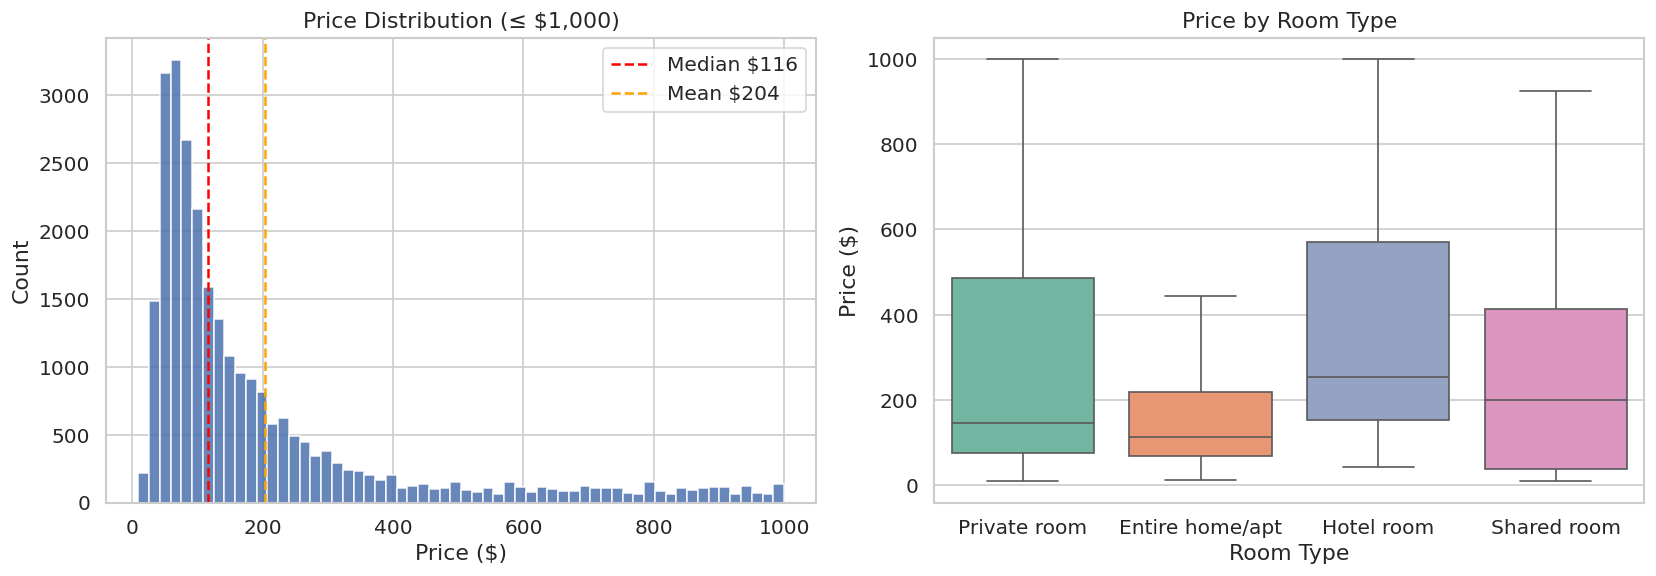

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
price_cap = df['price'][df['price'] <= 1000]
axes[0].hist(price_cap, bins=60, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(price_cap.median(), color='red', ls='--', lw=1.5, label=f'Median ${price_cap.median():.0f}')
axes[0].axvline(price_cap.mean(), color='orange', ls='--', lw=1.5, label=f'Mean ${price_cap.mean():.0f}')
axes[0].set(xlabel='Price ($)', ylabel='Count', title='Price Distribution (≤ $1,000)')
axes[0].legend()
sns.boxplot(data=df[df['price'] <= 1000], x='room_type', y='price', ax=axes[1], palette='Set2', showfliers=False)
axes[1].set(title='Price by Room Type', xlabel='Room Type', ylabel='Price ($)')
plt.tight_layout()
plt.show()

### 2.2 Revenue by Neighbourhood (Top 15)

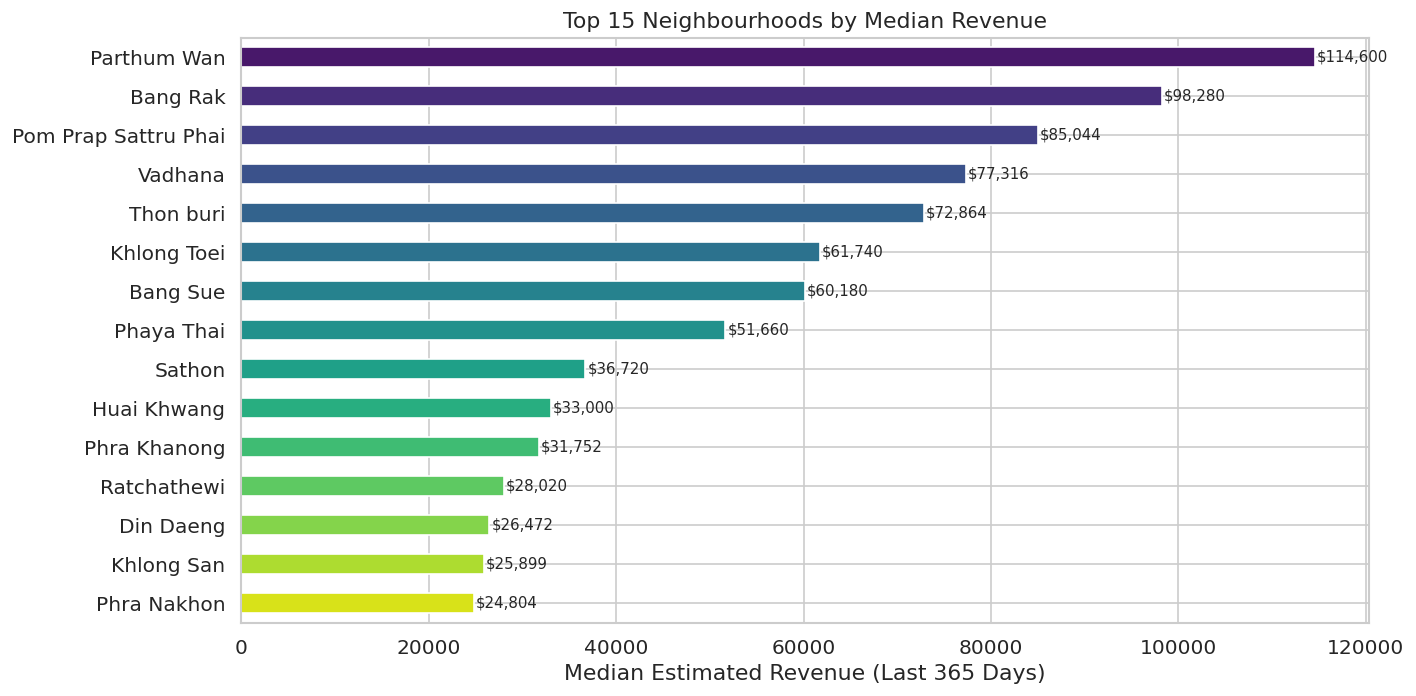

In [49]:
rev_by_hood = (df.groupby('neighbourhood_cleansed')['estimated_revenue_l365d']
               .median().sort_values(ascending=False).head(15))
fig, ax = plt.subplots(figsize=(12, 6))
rev_by_hood.plot(kind='barh', color=sns.color_palette('viridis', 15), ax=ax, edgecolor='white')
ax.set(xlabel='Median Estimated Revenue (Last 365 Days)', ylabel='', title='Top 15 Neighbourhoods by Median Revenue')
ax.invert_yaxis()
for i, v in enumerate(rev_by_hood): ax.text(v + 200, i, f'${v:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 2.3 Revenue by Property Type (Top 10)

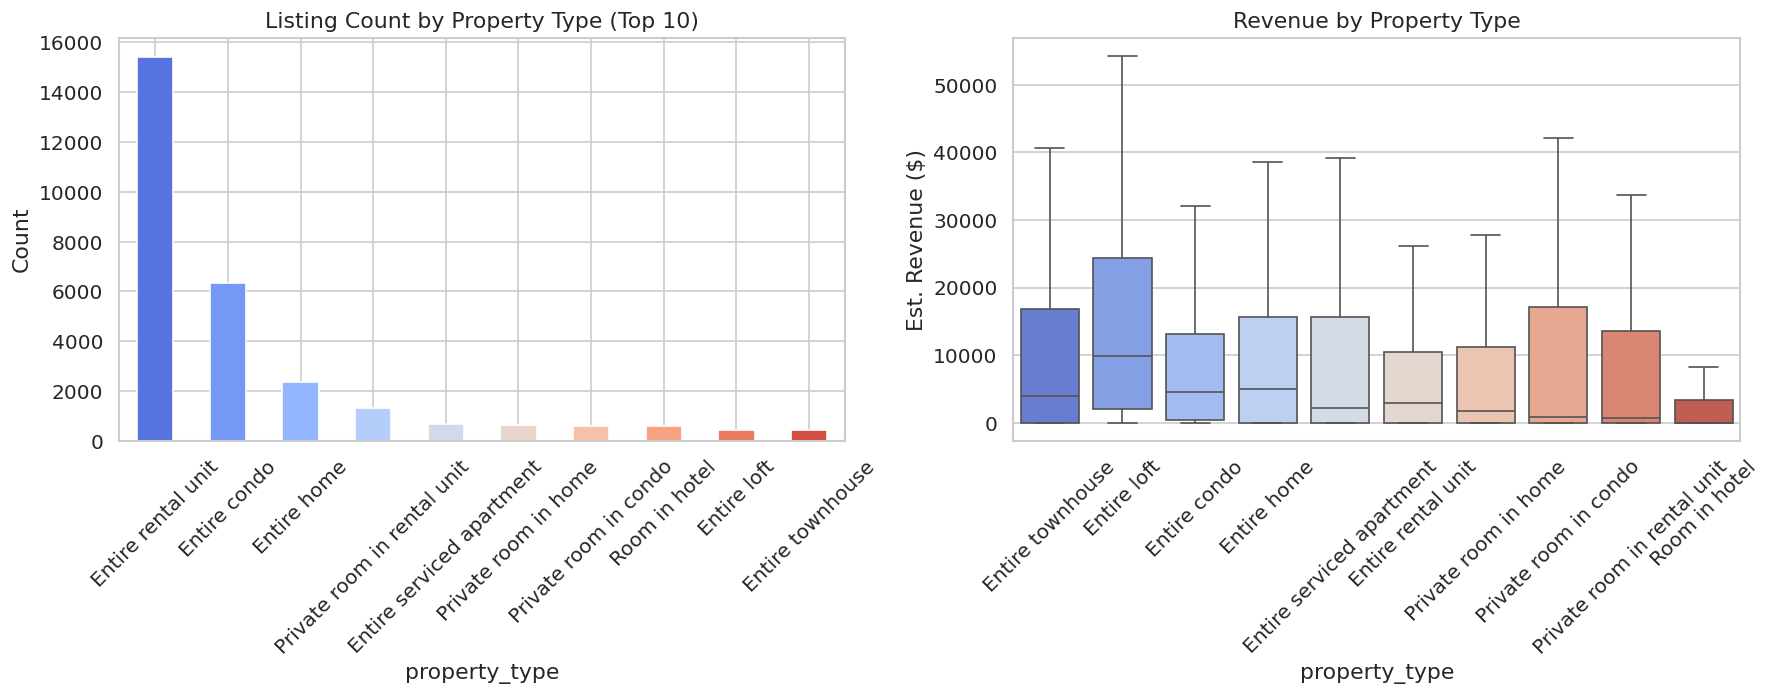

In [50]:
top_prop = df['property_type'].value_counts().head(10).index
df_top = df[df['property_type'].isin(top_prop)]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
df_top['property_type'].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette('coolwarm', 10), edgecolor='white')
axes[0].set(title='Listing Count by Property Type (Top 10)', ylabel='Count')
axes[0].tick_params(axis='x', rotation=45)
order = df_top.groupby('property_type')['estimated_revenue_l365d'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top[df_top['estimated_revenue_l365d'] <= 80000], x='property_type', y='estimated_revenue_l365d', order=order, ax=axes[1], palette='coolwarm', showfliers=False)
axes[1].set(title='Revenue by Property Type', ylabel='Est. Revenue ($)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 2.4 Room Type Breakdown

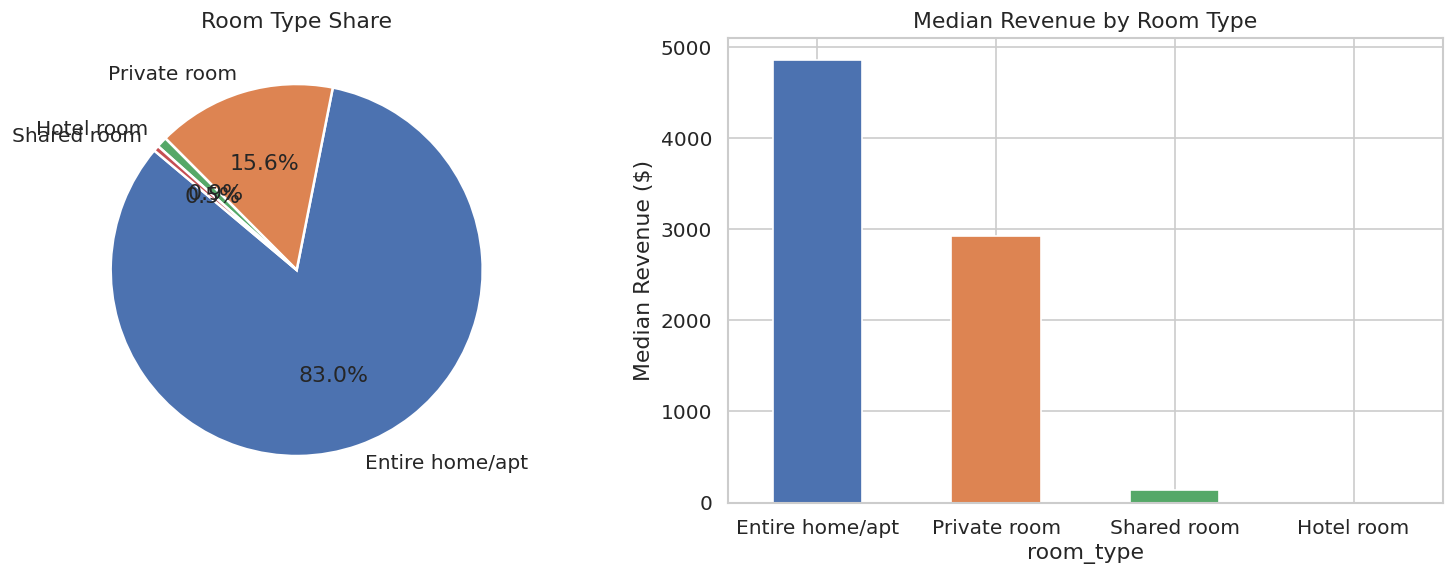

In [51]:
room_counts = df['room_type'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
axes[0].pie(room_counts, labels=room_counts.index, autopct='%1.1f%%', colors=colors, startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Room Type Share')
room_rev = df.groupby('room_type')['estimated_revenue_l365d'].median().sort_values(ascending=False)
room_rev.plot(kind='bar', ax=axes[1], color=colors[:len(room_rev)], edgecolor='white')
axes[1].set(title='Median Revenue by Room Type', ylabel='Median Revenue ($)')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### 2.5 Price vs. Accommodates

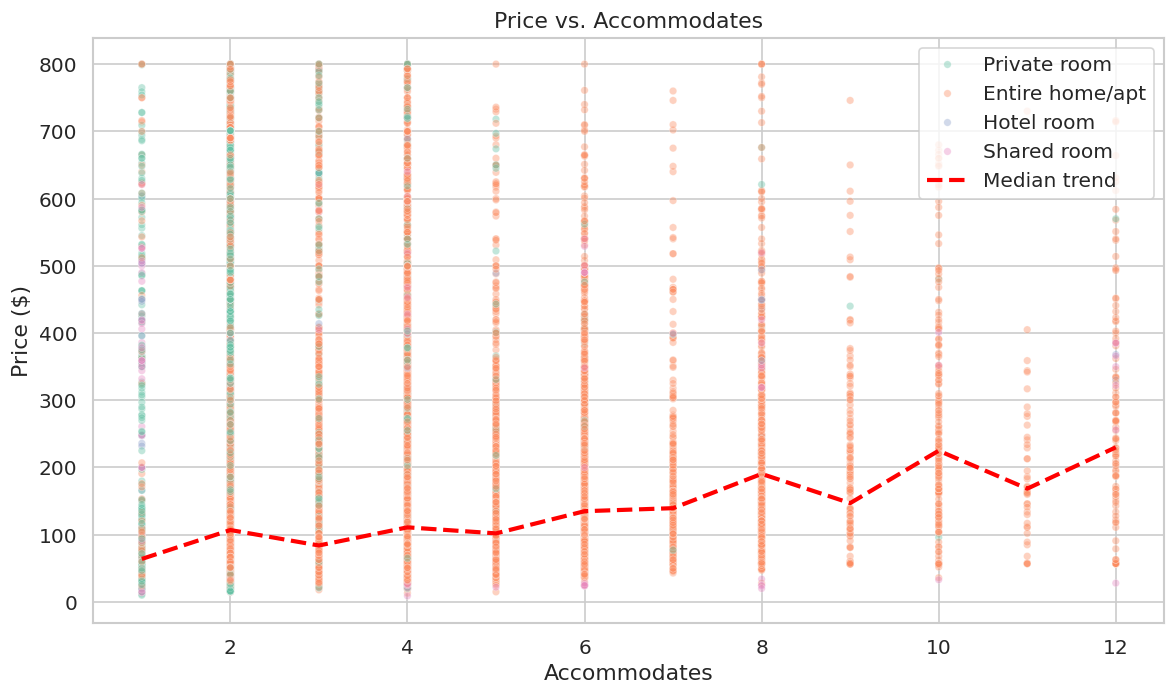

In [52]:
fig, ax = plt.subplots(figsize=(10, 6))
subset = df[(df['price'] <= 800) & (df['accommodates'] <= 12)]
sns.scatterplot(data=subset, x='accommodates', y='price', hue='room_type', alpha=0.4, s=20, ax=ax, palette='Set2')
means = subset.groupby('accommodates')['price'].median()
ax.plot(means.index, means.values, color='red', lw=2.5, ls='--', label='Median trend')
ax.set(title='Price vs. Accommodates', xlabel='Accommodates', ylabel='Price ($)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3 — User Perspective
### 3.1 Review Score Distributions

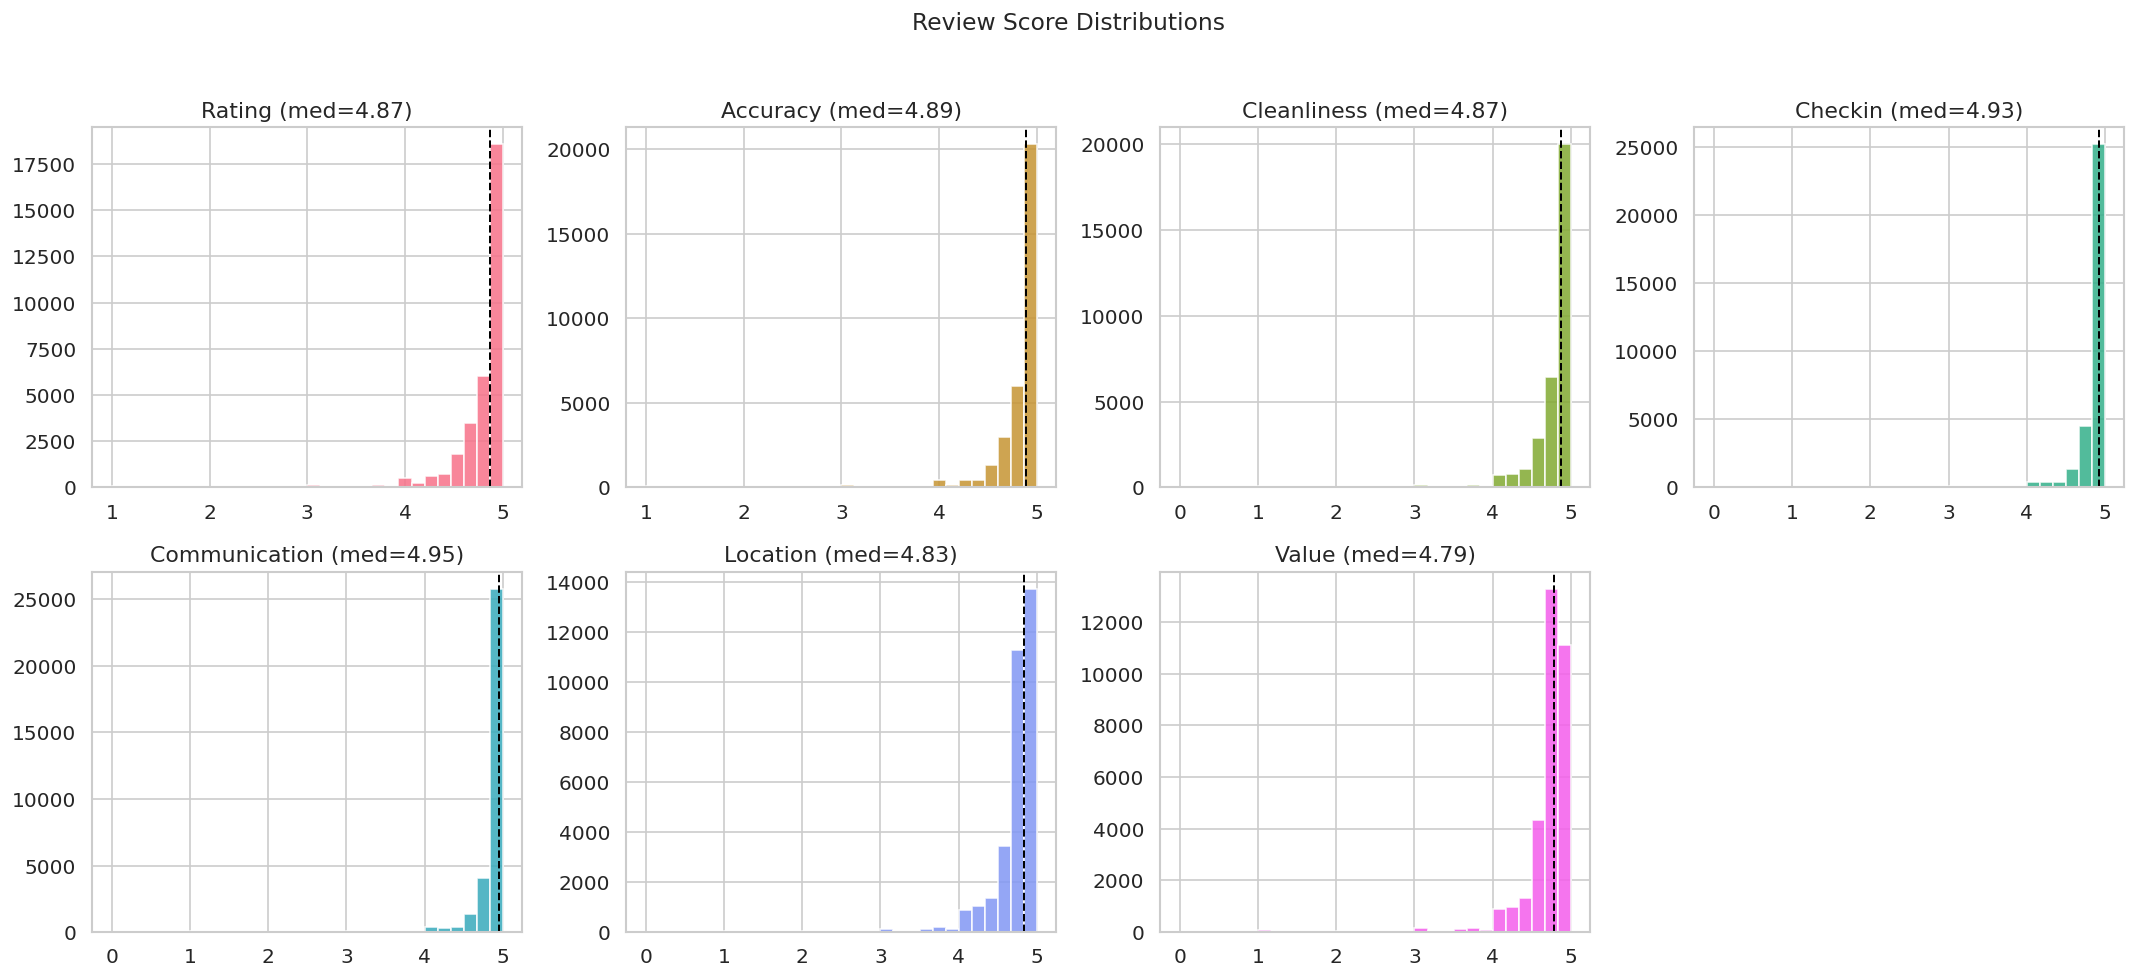

In [53]:
review_cols = ['review_scores_rating','review_scores_accuracy','review_scores_cleanliness',
               'review_scores_checkin','review_scores_communication','review_scores_location','review_scores_value']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(review_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=30, color=sns.color_palette('husl', 7)[i], edgecolor='white', alpha=0.85)
    axes[i].axvline(data.median(), color='black', ls='--', lw=1.2)
    axes[i].set_title(f"{col.replace('review_scores_','').title()} (med={data.median():.2f})")
axes[-1].axis('off')
plt.suptitle('Review Score Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Review Scores — Correlation Heatmap

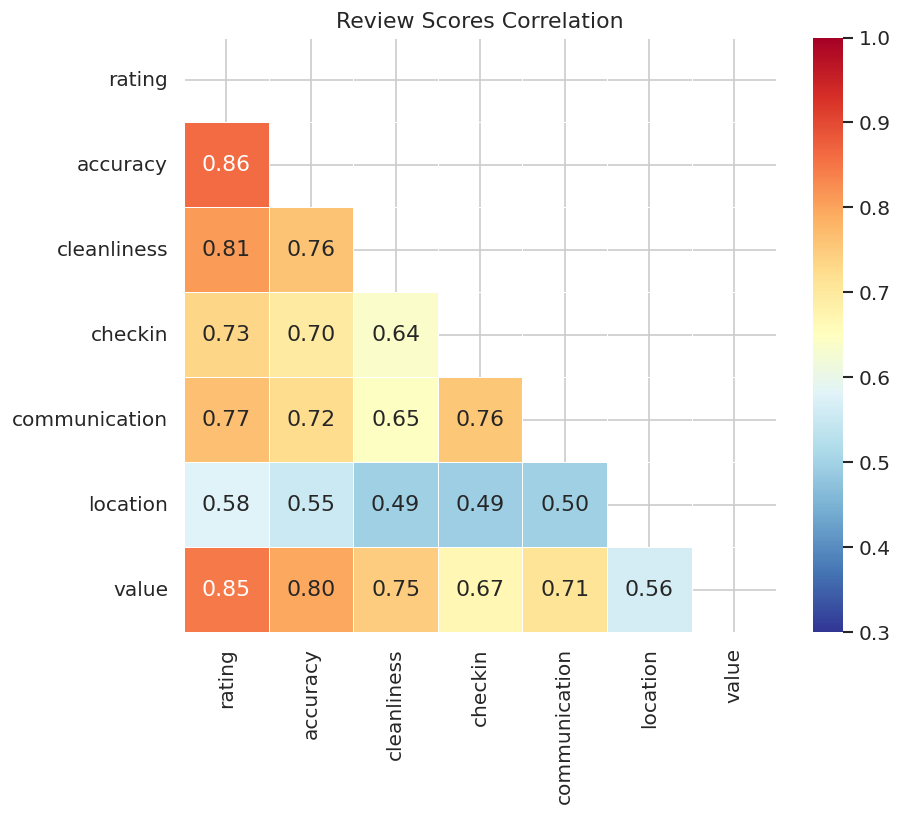

In [54]:
corr = df[review_cols].corr()
fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
labels = [c.replace('review_scores_','') for c in review_cols]
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r', vmin=0.3, vmax=1, linewidths=0.5, ax=ax, xticklabels=labels, yticklabels=labels)
ax.set_title('Review Scores Correlation')
plt.tight_layout()
plt.show()

### 3.3 Superhost vs. Non-Superhost

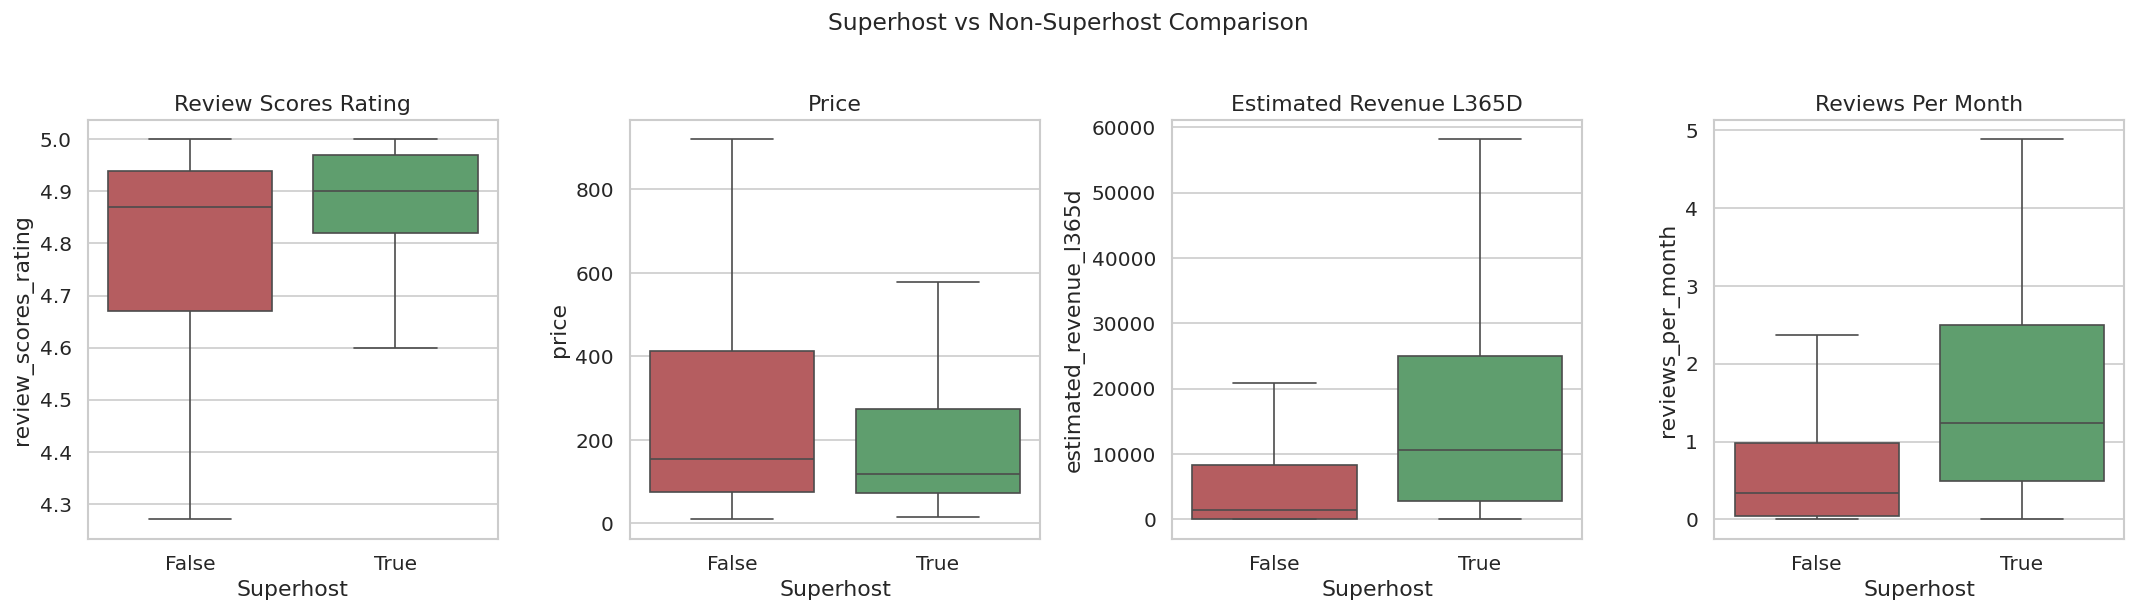

              review_scores_rating  price  estimated_revenue_l365d  reviews_per_month
is_superhost                                                                         
False                         4.87  170.0                   1714.0               0.36
True                          4.90  125.0                  12240.0               1.43


In [55]:
# host_is_superhost is float64: 1.0 = superhost, 0.0 = not
df['is_superhost'] = df['host_is_superhost'] == 1.0
compare_cols = ['review_scores_rating','price','estimated_revenue_l365d','reviews_per_month']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(compare_cols):
    data = df[[col,'is_superhost']].dropna()
    data = data[data[col] <= data[col].quantile(0.95)]
    sns.boxplot(data=data, x='is_superhost', y=col, ax=axes[i], palette=['#C44E52','#55A868'], showfliers=False)
    axes[i].set_title(col.replace('_',' ').title())
    axes[i].set_xlabel('Superhost')
plt.suptitle('Superhost vs Non-Superhost Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print(df.groupby('is_superhost')[compare_cols].median().round(2).to_string())

### 3.4 Top-Rated Neighbourhoods

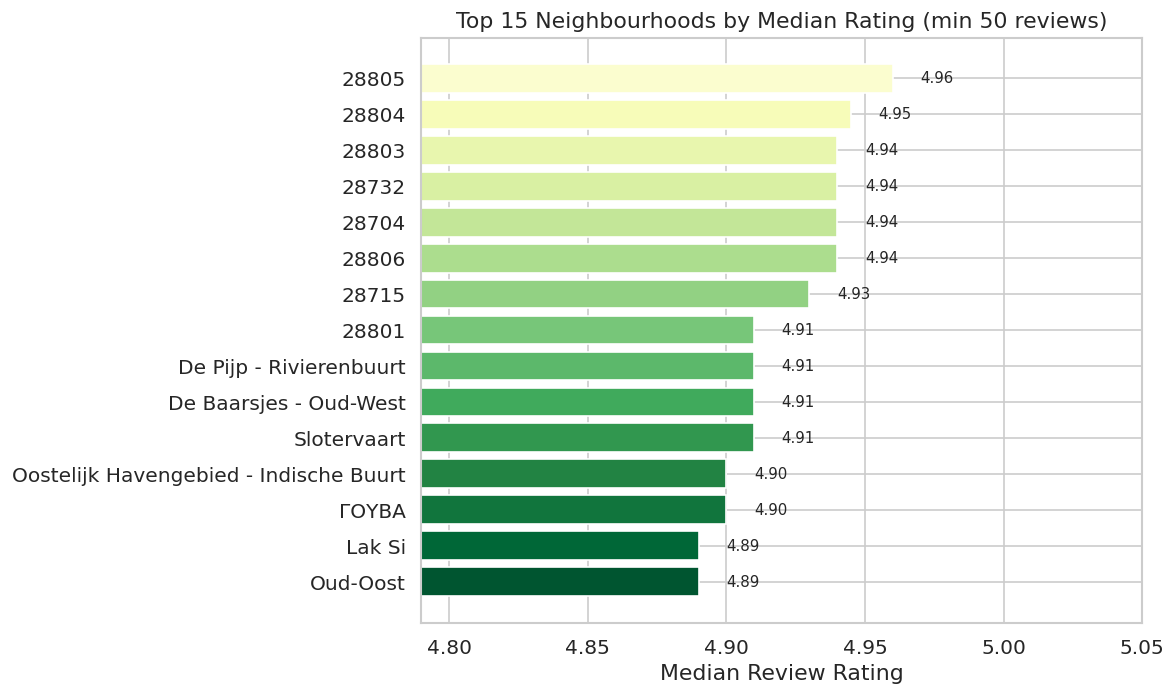

In [56]:
hood_reviews = (df.groupby('neighbourhood_cleansed')
    .agg(median_rating=('review_scores_rating','median'), count=('review_scores_rating','count'))
    .query('count >= 50').sort_values('median_rating', ascending=False).head(15))
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(hood_reviews.index, hood_reviews['median_rating'], color=sns.color_palette('YlGn', 15), edgecolor='white')
ax.set(xlabel='Median Review Rating', title='Top 15 Neighbourhoods by Median Rating (min 50 reviews)')
ax.invert_yaxis()
ax.set_xlim(hood_reviews['median_rating'].min() - 0.1, 5.05)
for i, v in enumerate(hood_reviews['median_rating']): ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 4 — Platform / Growth Perspective
### 4.1 Availability Patterns

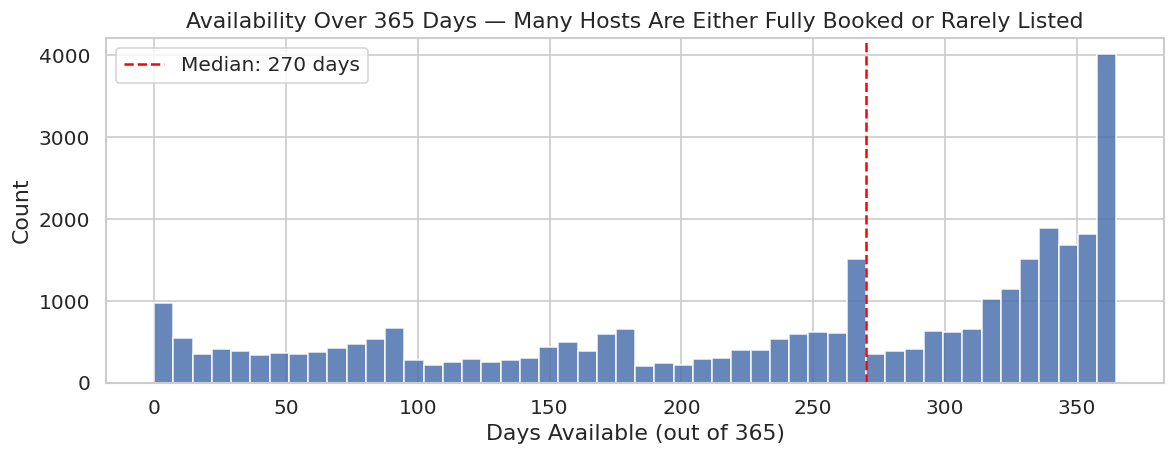

In [57]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['availability_365'].dropna(), bins=50, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.axvline(df['availability_365'].median(), color='red', ls='--', lw=1.5,
           label=f"Median: {df['availability_365'].median():.0f} days")
ax.set(title='Availability Over 365 Days — Many Hosts Are Either Fully Booked or Rarely Listed',
       xlabel='Days Available (out of 365)', ylabel='Count')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Occupancy & Revenue Distribution

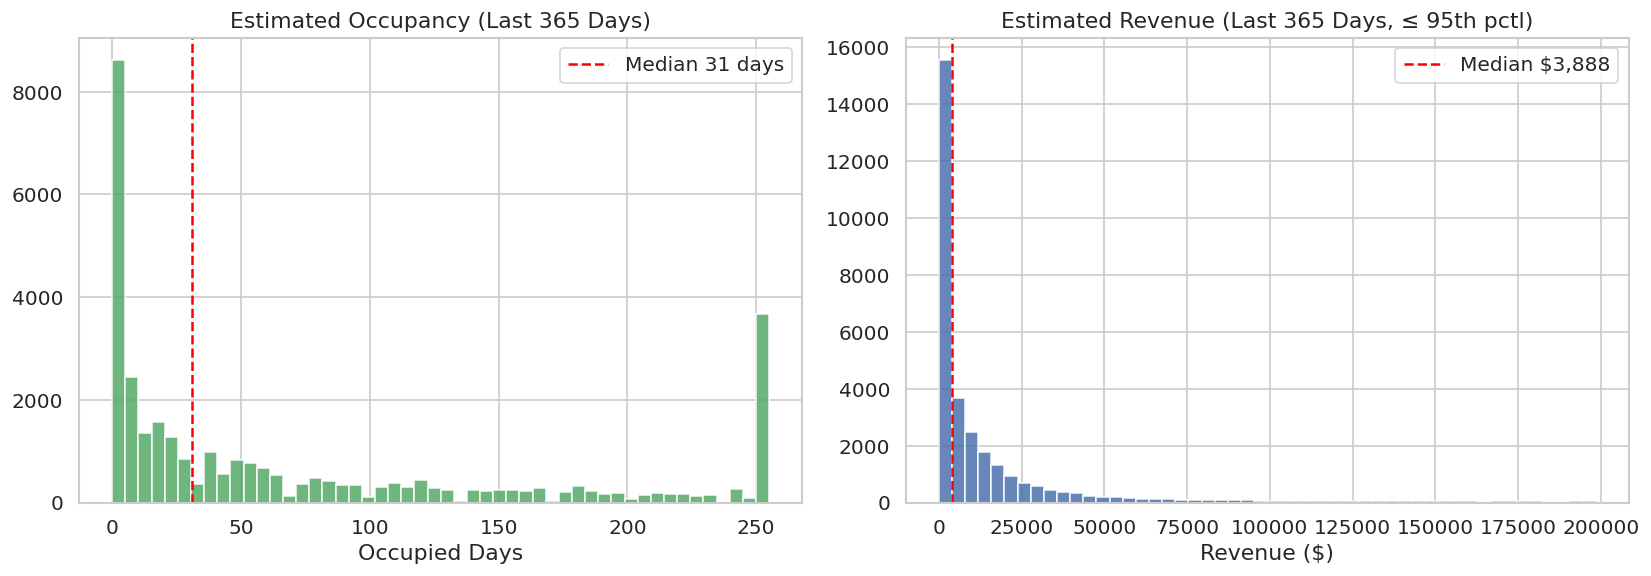

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
occ = df['estimated_occupancy_l365d'].dropna()
axes[0].hist(occ, bins=50, color='#55A868', edgecolor='white', alpha=0.85)
axes[0].axvline(occ.median(), color='red', ls='--', lw=1.5, label=f'Median {occ.median():.0f} days')
axes[0].set(title='Estimated Occupancy (Last 365 Days)', xlabel='Occupied Days')
axes[0].legend()
rev = df['estimated_revenue_l365d'].dropna()
rev_cap = rev[rev <= rev.quantile(0.95)]
axes[1].hist(rev_cap, bins=50, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[1].axvline(rev_cap.median(), color='red', ls='--', lw=1.5, label=f'Median ${rev_cap.median():,.0f}')
axes[1].set(title='Estimated Revenue (Last 365 Days, ≤ 95th pctl)', xlabel='Revenue ($)')
axes[1].legend()
plt.tight_layout()
plt.show()

### 4.3 Instant Bookable & Minimum Nights

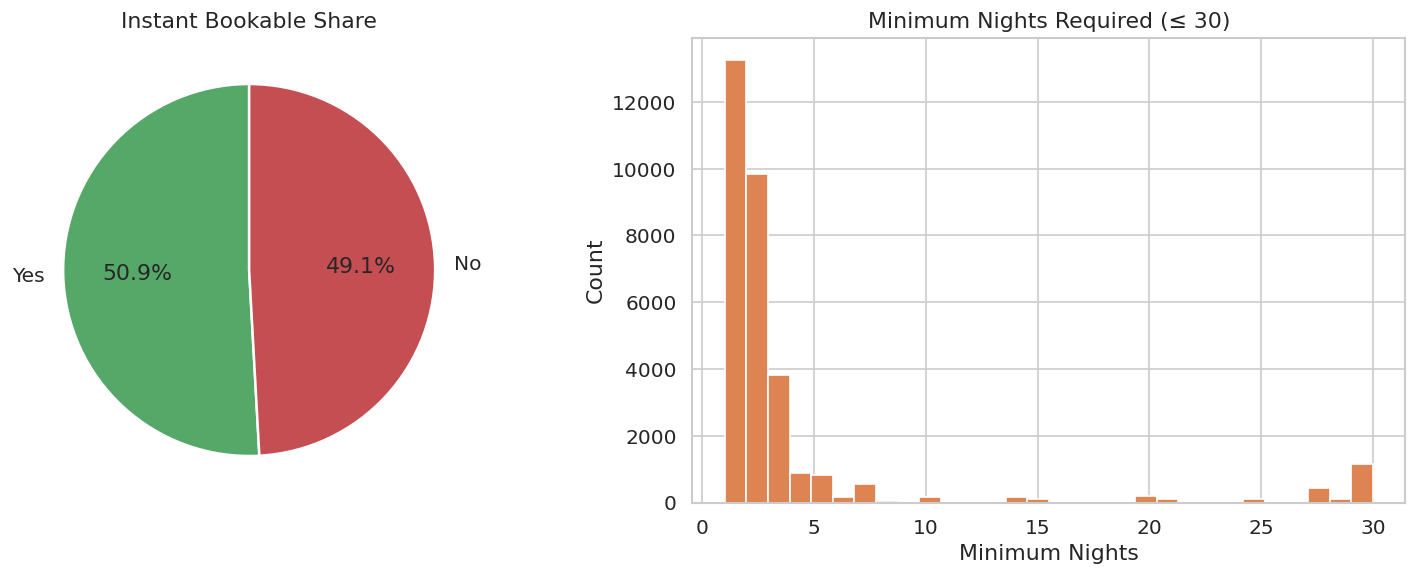

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# instant_bookable is float64: 1.0 = Yes, 0.0 = No
ib = df['instant_bookable'].map({1.0:'Yes', 0.0:'No'}).value_counts()
axes[0].pie(ib, labels=ib.index, autopct='%1.1f%%', colors=['#55A868','#C44E52'], startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Instant Bookable Share')
mn = df['minimum_nights'][(df['minimum_nights'] > 0) & (df['minimum_nights'] <= 30)]
axes[1].hist(mn, bins=30, color='#DD8452', edgecolor='white')
axes[1].set(title='Minimum Nights Required (≤ 30)', xlabel='Minimum Nights', ylabel='Count')
plt.tight_layout()
plt.show()

---
## 5 — Geographic Analysis

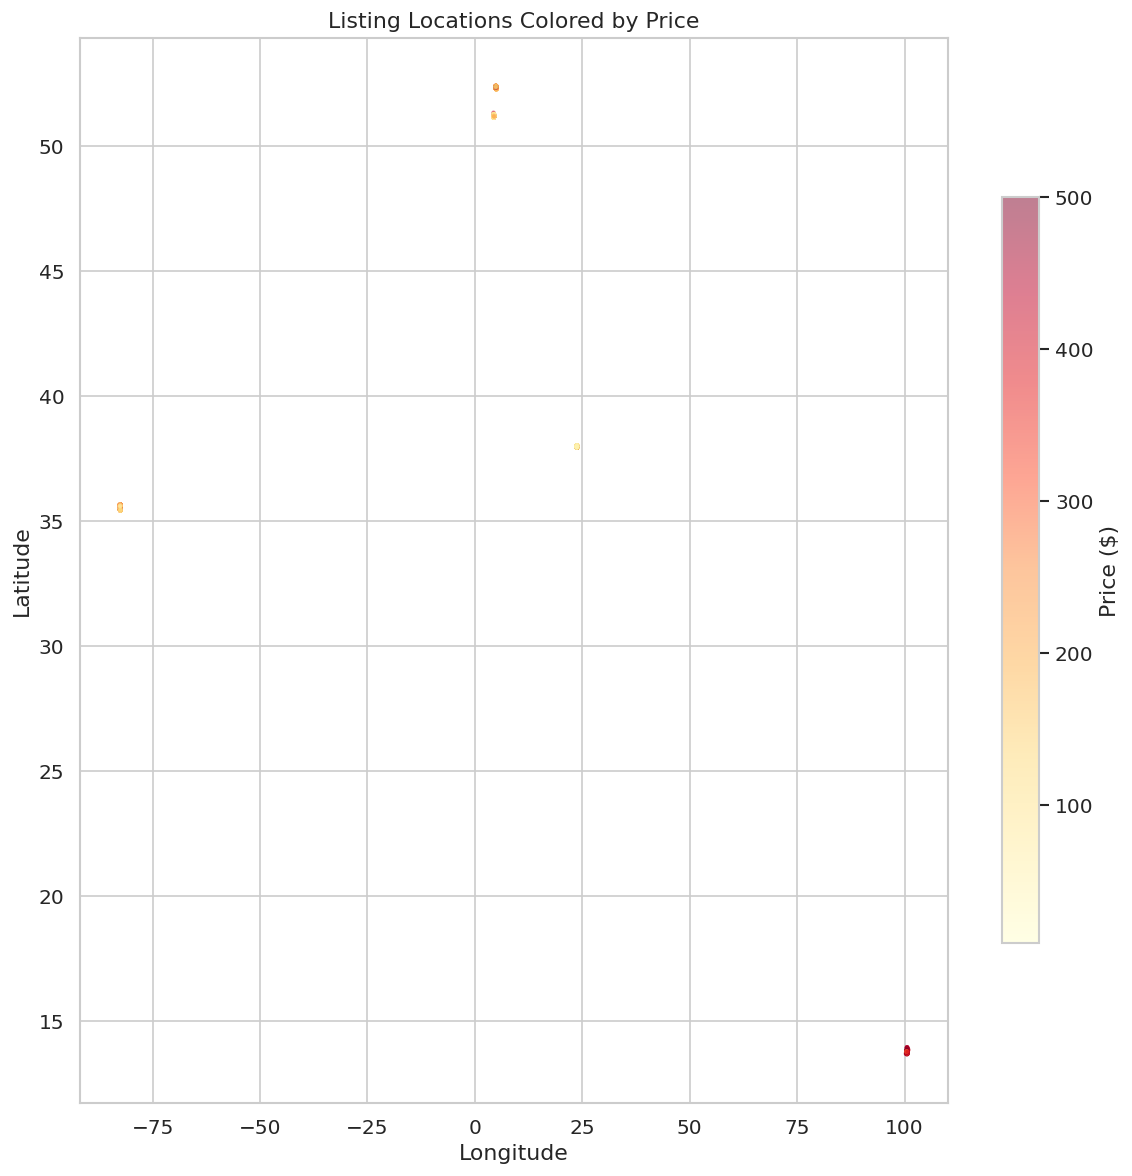

In [60]:
geo = df[['latitude','longitude','price']].dropna()
geo = geo[(geo['price'] > 0) & (geo['price'] <= 500)]
fig, ax = plt.subplots(figsize=(10, 10))
sc = ax.scatter(geo['longitude'], geo['latitude'], c=geo['price'], cmap='YlOrRd', s=3, alpha=0.5)
plt.colorbar(sc, ax=ax, label='Price ($)', shrink=0.7)
ax.set(xlabel='Longitude', ylabel='Latitude', title='Listing Locations Colored by Price')
plt.tight_layout()
plt.show()

---
## 6 — Full Numeric Correlation Heatmap

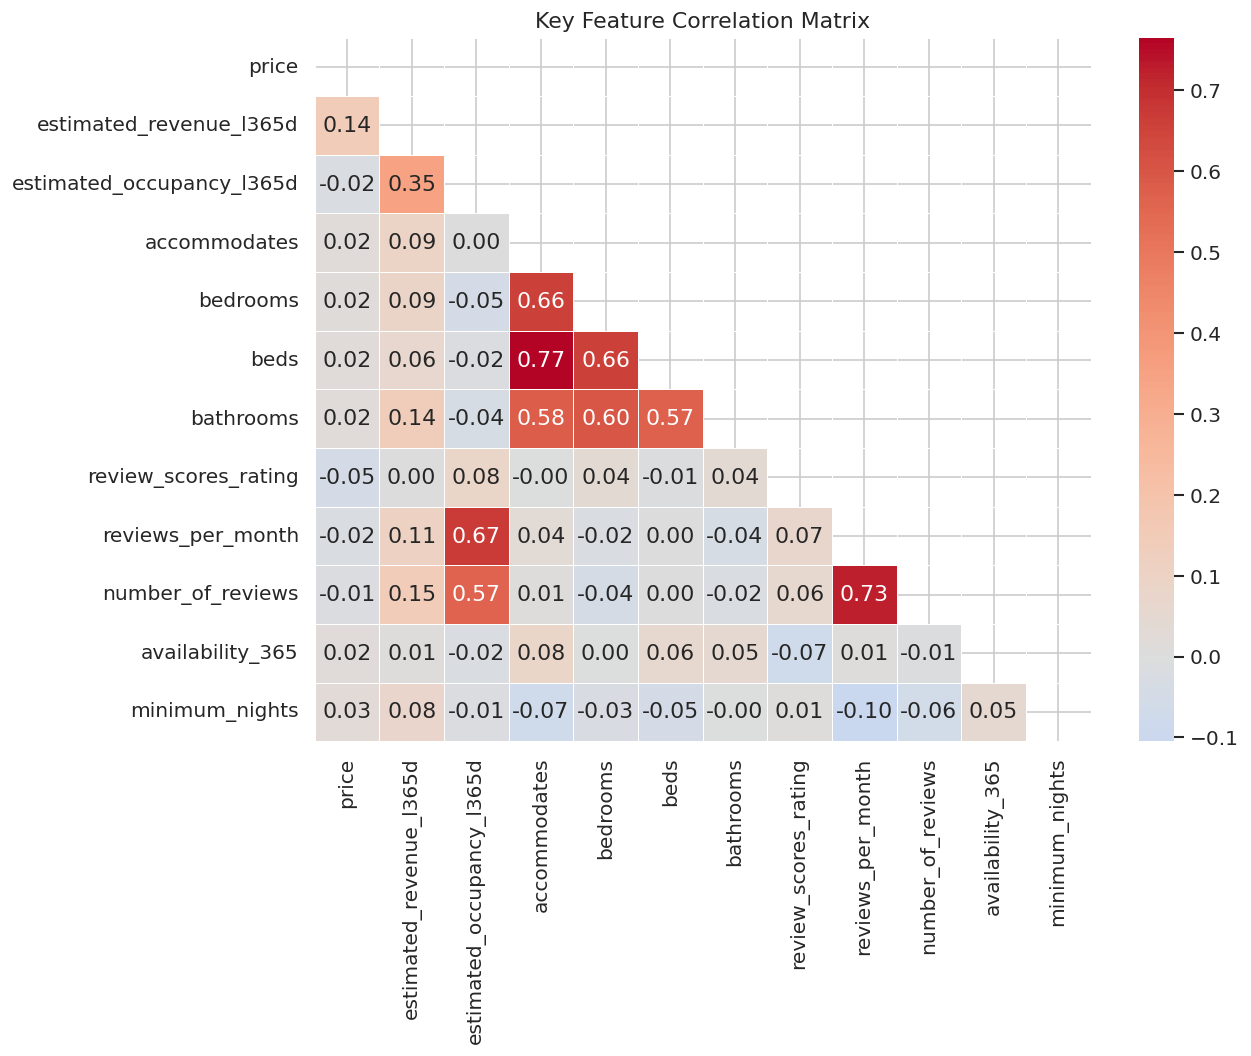

In [61]:
key_nums = ['price','estimated_revenue_l365d','estimated_occupancy_l365d','accommodates',
            'bedrooms','beds','bathrooms','review_scores_rating','reviews_per_month',
            'number_of_reviews','availability_365','minimum_nights']
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(df[key_nums].corr(), dtype=bool))
sns.heatmap(df[key_nums].corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Key Feature Correlation Matrix')
plt.tight_layout()
plt.show()

---
## 7 — Key Takeaways

| Perspective | Finding |
|---|---|
| **Business** | Price is heavily right-skewed — most listings are budget/mid-range. Entire homes command the highest revenue. Central neighbourhoods dominate revenue. Price scales linearly with capacity. |
| **User** | Review scores are left-skewed (most > 4.5). All review dimensions are highly correlated. Superhosts earn higher ratings AND more revenue. |
| **Platform** | Majority of listings are entire homes/apartments. Many listings have very low availability. Occupancy distribution is bimodal. |
| **Geographic** | Premium pricing clusters in city centres. Peripheral areas are predominantly budget listings. |